For a visualisation of this simulation, please visit https://edu.nl/ceeqc .
Ray Optics Simulation, 
Tu, Yi-Time and others, 2025, doi:10.5281/zenodo.15265643, https://phydemo.app/ray-optics/

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
diameter_cup = 28e-3  # in meters
distance_grid_to_camera = 200e-3  # in meters
grid_height = 3e-3 

n_ethane = 1.153 # Fitted value using the ratio of pixel diameters of the grid with and without ethane cup (without ethane, diameter = 123pix, with ethane, diameter = 149pix)

In [3]:
radius_cup = diameter_cup / 2
h = grid_height / 2 
# angle of refraction from cup to air 
theta_1 = np.arcsin( h / radius_cup )
theta_2 = np.arcsin( n_ethane * np.sin(theta_1) )
delta_theta = theta_2 - theta_1
# image height 
h_image = distance_grid_to_camera * np.tan(delta_theta) - h 
image_height = 2 * h_image

print(f"Image height: {image_height * 1e3:.2f} mm")


Image height: 3.60 mm


In [4]:
def get_image_height_from_input_height(input_height, radius_cup, distance_grid_to_camera, n_ethane):
    """Calculate the image height based on input height."""
    h = input_height / 2
    theta_1 = np.arcsin(h / radius_cup)
    theta_2 = np.arcsin(n_ethane * np.sin(theta_1))
    delta_theta = theta_2 - theta_1
    h_image = distance_grid_to_camera * np.tan(delta_theta) - h
    return 2 * h_image


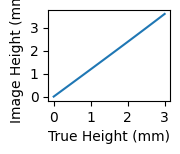

In [5]:
from matplotlib import rcParams
object_heights = np.linspace(0, 3e-3, 100)  # from 0 to 10 mm
image_heights = get_image_height_from_input_height(object_heights, radius_cup=14e-3, distance_grid_to_camera=distance_grid_to_camera, n_ethane=1.153)
figsize_mm = (40, 30)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
rcParams['pdf.fonttype'] = 42 
plt.figure(figsize=figsize_in)
plt.plot(object_heights * 1e3, image_heights * 1e3, label='Image Height vs Object Height')
#plt.title('Image Height vs Object Height')
plt.xlabel('True Height (mm)')
plt.ylabel('Image Height (mm)')
plt.xticks([0, 1, 2, 3], ['0', '1', '2', '3'])
plt.yticks([0, 1, 2, 3], ['0', '1', '2', '3'])
# save 
save_path = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/other/image_height_vs_object_height.pdf"
plt.savefig(save_path, bbox_inches='tight', dpi=600)



/tmp/ipykernel_6767/1079620739.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = image_height / object_heights


array([         inf, 118.8618928 ,  59.4309464 ,  39.62063093,
        29.7154732 ,  23.77237856,  19.81031547,  16.9802704 ,
        14.8577366 ,  13.20687698,  11.88618928,  10.80562662,
         9.90515773,   9.14322252,   8.4901352 ,   7.92412619,
         7.4288683 ,   6.99187605,   6.60343849,   6.25588909,
         5.94309464,   5.66009013,   5.40281331,   5.16790838,
         4.95257887,   4.75447571,   4.57161126,   4.40229233,
         4.2450676 ,   4.09868596,   3.96206309,   3.83425461,
         3.71443415,   3.60187554,   3.49593802,   3.39605408,
         3.30171924,   3.21248359,   3.12794455,   3.04774084,
         2.97154732,   2.89907056,   2.83004507,   2.76423007,
         2.70140665,   2.6413754 ,   2.58395419,   2.52897644,
         2.47628943,   2.42575291,   2.37723786,   2.33062535,
         2.28580563,   2.24267722,   2.20114616,   2.16112532,
         2.1225338 ,   2.08529636,   2.04934298,   2.01460835,
         1.98103155,   1.94855562,   1.9171273 ,   1.88